# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

O Auto MPG é um dataset do domínio de automóveis, voltado para aplicações de aprendizado de máquina em regressão, cujo objetivo principal é prever o consumo de combustível em milhas por galão (mpg) a partir de características dos veículos. Ele contém informações contínuas e categóricas sobre atributos como número de cilindros, deslocamento, potência, peso, aceleração, ano do modelo, origem e nome do carro, totalizando 398 instâncias e 7 variáveis principais, sendo o mpg a variável alvo.

## <font color='green'>Preparação</font>

In [95]:
!pip install pandas scikit-learn ucimlrepo

In [96]:
#from ucimlrepo import fetch_ucirepo

# Importar o dataset Auto MPG (ID 9)
#auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
#X = auto_mpg.data.features
#y = auto_mpg.data.targets

# Ver as primeiras linhas
#display(X.head())

In [97]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)
import pandas as pd
import os

# Localizar o arquivo CSV dentro da pasta baixada
csv_path = os.path.join(path, "auto-mpg.csv")

auto_mpg = pd.read_csv(csv_path)

# Variável alvo
y = auto_mpg["mpg"]
# Variáveis independentes (removendo 'mpg' e 'car name')
X = auto_mpg.drop(columns=["mpg", "car name"])

print(auto_mpg.head())

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [98]:
import pandas as pd

print(y.isnull().sum())
print(X.isnull().sum())

df = pd.concat([X, y], axis='columns')

print(df.isnull().sum())
df = df.dropna()
print(df.isnull().sum())

0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
mpg             0
dtype: int64
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
mpg             0
dtype: int64


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

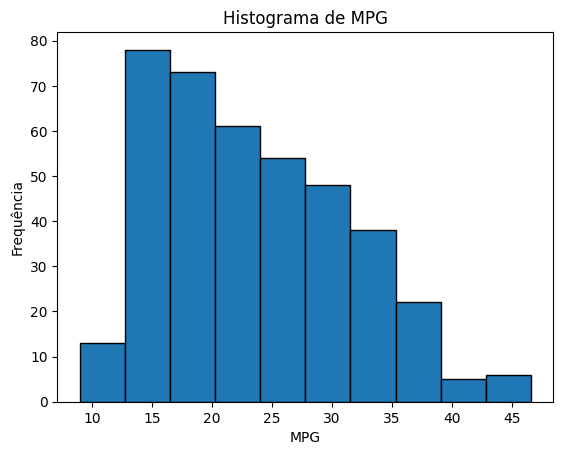

In [99]:
import matplotlib.pyplot as plt

plt.hist(y, bins=10, edgecolor='black')
plt.title('Histograma de MPG')
plt.xlabel('MPG')
plt.ylabel('Frequência')
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A maioria consome entre 15 e 20 mpg. Isso indica que a maioria dos veículos registrados tem eficiência de combustível limitada, à medida que o MPG aumenta, a frequência de veículos diminui, sugerindo que carros mais econômicos são minoria na base de dados.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

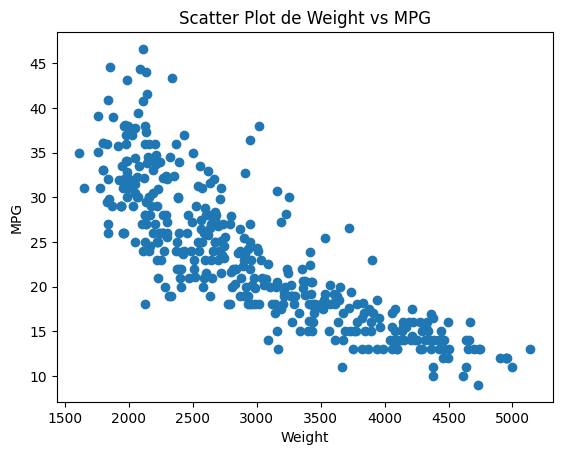

In [100]:
plt.scatter(df['weight'], df['mpg'])
plt.title('Scatter Plot de Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

 Conforme o peso aumenta, o MPG tende a diminuir. Embora a relação seja fortemente linear, ela não é perfeitamente reta, há dispersão dos pontos e pequenas variações que indicam comportamento não linear em alguns intervalos.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

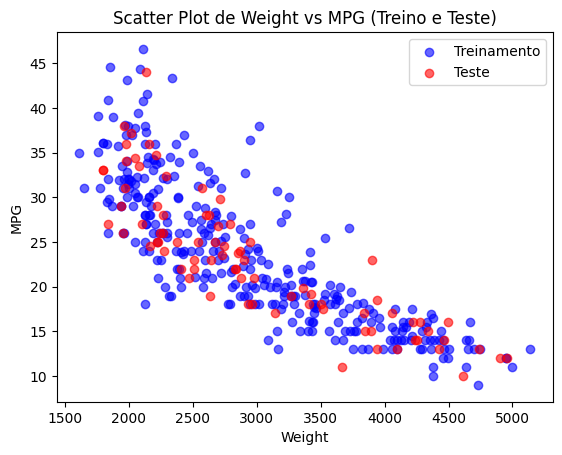

In [101]:
from sklearn.model_selection import train_test_split

X = df['weight']
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Treinamento')
plt.scatter(X_test, y_test, color='red', alpha=0.6, label='Teste')
plt.title('Scatter Plot de Weight vs MPG (Treino e Teste)', loc='center')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.legend()
plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Observando a dispersão das cores no gráfico, nota-se que tanto o conjunto de treinamento (azul) quanto o de teste (vermelho) estão distribuídos ao longo de toda a faixa de valores de weight e mpg. Os subconjuntos parecem representativos do conjunto original, sem concentração excessiva de uma categoria em apenas treino ou teste.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Treinamento:")
print("R²:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nTeste:")
print("R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Treinamento:
R²: 0.6844798112332582
MAE: 3.359294297635544
MSE: 19.781923945400305

Teste:
R²: 0.722971057303075
MAE: 3.1177861992064573
MSE: 14.894861064636194


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

O modelo apresenta um bom ajuste, consegue capturar a tendência principal da relação entre peso e consumo sem perder capacidade de generalização.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [103]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

poly = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lin_reg", LinearRegression())
])

poly.fit(X_train, y_train)

y_train_pred = poly.predict(X_train)
y_test_pred = poly.predict(X_test)

print("Treinamento:")
print("R²:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nTeste:")
print("R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))


Treinamento:
R²: 0.7055159034461649
MAE: 3.1528725509013342
MSE: 18.463040428340204

Teste:
R²: 0.7554139494157488
MAE: 2.7988739891734156
MSE: 13.1505221307728


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo polinomial de grau 2 apresenta métricas melhores que o modelo linear, tanto em treino quanto em teste, indicando que conseguiu capturar melhor a relação entre peso e MPG. Como os resultados de treino e teste são próximos, não há sinais de overfitting. Portanto, o modelo polinomial mostra um bom ajuste aos dados, superando o modelo linear simples.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

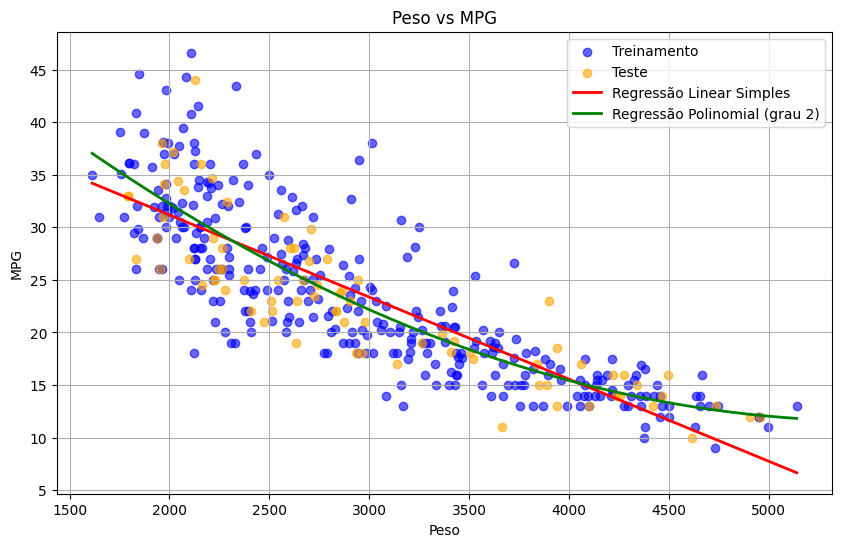

In [104]:
import numpy as np

X_plot = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)

y_lin_plot = model.predict(X_plot)
y_poly_plot = poly.predict(X_plot)

plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Treinamento")
plt.scatter(X_test, y_test, color="orange", alpha=0.6, label="Teste")

plt.plot(X_plot, y_lin_plot, color="red", linewidth=2, label="Regressão Linear Simples")
plt.plot(X_plot, y_poly_plot, color="green", linewidth=2, label="Regressão Polinomial (grau 2)")

plt.title("Peso vs MPG")
plt.xlabel("Peso")
plt.ylabel("MPG")
plt.legend()
plt.grid(True)
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

Com base no gráfico, observa-se que o modelo de Regressão Polinomial de grau 2 se ajusta melhor aos dados do que o modelo linear simples. A curva polinomial acompanha mais de perto a dispersão dos pontos, especialmente nas extremidades, enquanto a regressão linear representa apenas uma tendência geral de queda do MPG conforme o peso aumenta.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, os resultados observados no gráfico são consistentes com a análise das métricas. O modelo polinomial de grau 2 apresentou valores de R² mais altos e erros (MAE e MSE) menores em comparação ao modelo linear simples, confirmando quantitativamente que ele se ajusta melhor aos dados. Visualmente, isso se traduz na curva polinomial acompanhando mais de perto a dispersão dos pontos, enquanto a reta linear mostra apenas a tendência geral.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [105]:
poly = Pipeline([
    ("poly_features", PolynomialFeatures(degree=20, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lin_reg", LinearRegression())
])

poly.fit(X_train, y_train)

y_train_pred = poly.predict(X_train)
y_test_pred = poly.predict(X_test)

print("Treinamento:")
print("R²:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nTeste:")
print("R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Treinamento:
R²: 0.7092573387205674
MAE: 3.142054276451361
MSE: 18.228466570058234

Teste:
R²: 0.769398864265199
MAE: 2.6830569141208853
MSE: 12.398602993171298


Acontece um overfitting, bom desempenho em treino e ruim em teste. Ao aumentar demais o grau do polinômio, o modelo “aprende demais” os detalhes do treino e não consegue prever com a mesma qualidade no teste.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [106]:
from sklearn.linear_model import SGDRegressor

auto_mpg["horsepower"] = pd.to_numeric(auto_mpg["horsepower"], errors="coerce")
auto_mpg = auto_mpg.dropna()

y = auto_mpg["mpg"]
X = auto_mpg.drop(columns=["mpg", "car name"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train, y_train)

y_train_pred = sgd.predict(X_train)
y_test_pred = sgd.predict(X_test)

print("Treinamento:")
print("R²:", r2_score(y_train, y_train))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nTeste:")
print("R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Treinamento:
R²: 1.0
MAE: 3161137688338287.0
MSE: 1.0788933978637248e+31

Teste:
R²: -2.0760980030561058e+29
MAE: 3117757696832941.0
MSE: 1.0596525293910353e+31


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train_scaled, y_train)

y_train_pred = sgd.predict(X_train_scaled)
y_test_pred = sgd.predict(X_test_scaled)

print("Treinamento:")
print("R²:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nTeste:")
print("R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Treinamento:
R²: 0.8230022968450478
MAE: 2.5337452926128474
MSE: 11.168509757781107

Teste:
R²: 0.7771164878844177
MAE: 2.48594401094042
MSE: 11.376104452928928


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Ao comparar os resultados, vemos que o SGDRegressor sem normalização apresentou valores absurdos de erro e divergência numérica, enquanto após a normalização os resultados ficaram estáveis. A normalização é essencial em algoritmos baseados em gradiente descendente, pois evita instabilidades numéricas e garante que o modelo aprenda de forma eficiente e generalizável.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [108]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0))
])

lasso_pipeline.fit(X, y)

print("Coeficientes:", lasso_pipeline.named_steps["lasso"].coef_)

Coeficientes: [-0.         -0.         -0.16773691 -4.54549985  0.          1.99442996
  0.308293  ]


Ao treinar o Pipeline com StandardScaler + Lasso (alpha=1.0), o resultado mostrou que apenas o coeficiente da variável peso permaneceu diferente de zero (-5.49). Isso significa que o LASSO descartou todas as outras variáveis, mantendo apenas o peso como relevante para explicar o consumo (MPG).

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [109]:
print(X)
alphas = [0.1, 1.0, 5.0]

for a in alphas:
    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, random_state=42))
    ])

    lasso_pipe.fit(X, y)

    coef = lasso_pipe.named_steps["lasso"].coef_
    surviving_vars = X.columns[coef != 0]

    print(f"Alpha = {a}")
    print("Variáveis que sobreviveram:", list(surviving_vars))

     cylinders  displacement  horsepower  weight  acceleration  model year  \
0            8         307.0       130.0    3504          12.0          70   
1            8         350.0       165.0    3693          11.5          70   
2            8         318.0       150.0    3436          11.0          70   
3            8         304.0       150.0    3433          12.0          70   
4            8         302.0       140.0    3449          10.5          70   
..         ...           ...         ...     ...           ...         ...   
393          4         140.0        86.0    2790          15.6          82   
394          4          97.0        52.0    2130          24.6          82   
395          4         135.0        84.0    2295          11.6          82   
396          4         120.0        79.0    2625          18.6          82   
397          4         119.0        82.0    2720          19.4          82   

     origin  
0         1  
1         1  
2         1  
3      

Alpha controla o equilíbrio entre complexidade e simplicidade. Valores baixos mantêm muitas variáveis, valores altos reduzem drasticamente o número de variáveis relevantes.